In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib

# Load the centralized preprocessed dataset
ADJUSTED_FILE = pathlib.Path('data/adjusted/policecalls_adjusted_all.csv')
df = pd.read_csv(ADJUSTED_FILE, low_memory=False)
df['CDTS'] = pd.to_datetime(df['CDTS'])
print(f"Loaded {len(df):,} rows for analysis.")

Loaded 3,076,875 rows for analysis.


In [2]:
key_fields = [
    field
    for field in ["CDTS", "PRIORITY", "CALL_TYPE", "FINAL_DISPO", "ADDRESS", "CITY"]
    if field in df.columns
]

duplicate_mask = (
    df.duplicated(subset=["CALL_NUMBER", "CDTS"], keep=False)
    if "CALL_NUMBER" in df.columns
    else df.duplicated(keep=False)
)

quality_summary = pd.DataFrame(
    {
        "metric": [
            "rows_after_cleaning",
            "duplicate_rows",
            "date_min",
            "date_max",
            "distinct_call_types",
            "distinct_dispositions",
            "distinct_addresses",
        ],
        "value": [
            len(df),
            int(duplicate_mask.sum()),
            df["CDTS"].min(),
            df["CDTS"].max(),
            int(df["CALL_TYPE"].nunique(dropna=True))
            if "CALL_TYPE" in df.columns
            else np.nan,
            int(df["FINAL_DISPO"].nunique(dropna=True))
            if "FINAL_DISPO" in df.columns
            else np.nan,
            int(df["ADDRESS"].nunique(dropna=True))
            if "ADDRESS" in df.columns
            else np.nan,
        ],
    }
)

field_completeness = (
    df[key_fields]
    .notna()
    .mean()
    .mul(100)
    .round(2)
    .rename("non_null_pct")
    .reset_index()
    .rename(columns={"index": "field"})
)

coverage_by_year_month = (
    df.groupby(
        [df["CDTS"].dt.year.rename("year"), df["CDTS"].dt.month.rename("month")],
        observed=False,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(1, 13), fill_value=0)
)

display(quality_summary)
display(field_completeness)
display(coverage_by_year_month)

,metric,value
0,rows_after_cleaning,3076875
1,duplicate_rows,17663
2,date_min,2016-01-01 00:03:35
3,date_max,2026-04-27 06:29:31
4,distinct_call_types,249
5,distinct_dispositions,25
6,distinct_addresses,87966


,field,non_null_pct
0,CDTS,100.00
1,PRIORITY,100.00
2,CALL_TYPE,100.00
3,FINAL_DISPO,100.00
4,ADDRESS,97.02
5,CITY,100.00


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,24717,23345,25015,25633,27659,26558,28582,27121,26229,26352,23543,24456
2017,24014,23191,25909,25606,26604,26661,28356,27863,27600,27799,25510,27059
2018,25577,24347,26505,26389,29036,27906,28470,28411,27249,27496,25198,25780
2019,24827,22809,27378,27012,27263,28451,27808,28560,27743,28818,26194,25746
2020,26163,24893,24201,22982,25706,24548,26918,26333,25066,25331,22215,23121
2021,23435,21771,25530,24276,26138,26729,27172,26205,25584,26230,24832,24202
2022,23404,21332,25315,23553,27064,26030,23623,26737,26074,26065,22617,22715
2023,23549,21021,23440,23624,25346,24434,25499,24854,24046,24405,22524,23729
2024,21487,21464,23064,21315,23832,23145,24245,23537,22937,23575,21670,22237


## Create time-based features

In [3]:
df["year"] = df["CDTS"].dt.year
df["month"] = df["CDTS"].dt.month
# Keep as datetime (not Python date objects) for faster grouping/resampling.
df["day"] = df["CDTS"].dt.floor("D")
df["hour"] = df["CDTS"].dt.hour
df["day_of_week"] = df["CDTS"].dt.day_name()
df["is_weekend"] = df["CDTS"].dt.dayofweek >= 5

display(
    df[["CDTS", "year", "month", "day", "hour", "day_of_week", "is_weekend"]].head()
)

,CDTS,year,month,day,hour,day_of_week,is_weekend
0,2016-05-14 22:22:22,2016,5,2016-05-14,22,Saturday,True
1,2016-05-14 21:44:06,2016,5,2016-05-14,21,Saturday,True
2,2016-05-14 21:26:18,2016,5,2016-05-14,21,Saturday,True
3,2016-05-14 22:53:46,2016,5,2016-05-14,22,Saturday,True
4,2016-05-14 22:46:27,2016,5,2016-05-14,22,Saturday,True


## Creating flags for canceled calls and priority groups

In [4]:
df["FINAL_DISPO_upper"] = df["FINAL_DISPO"].str.upper()
df["is_canceled"] = df["FINAL_DISPO_upper"].str.contains("CANCEL", na=False)

df["is_p1"] = df["PRIORITY"] == 1
df["is_p3_p4"] = df["PRIORITY"].isin([3, 4])
df["is_canceled_p3_p4"] = df["is_canceled"] & df["is_p3_p4"]

display(
    df[
        [
            "PRIORITY",
            "FINAL_DISPO",
            "is_canceled",
            "is_p1",
            "is_p3_p4",
            "is_canceled_p3_p4",
        ]
    ].head()
)

,PRIORITY,FINAL_DISPO,is_canceled,is_p1,is_p3_p4,is_canceled_p3_p4
0,3,No report required; dispatch r,False,False,True,False
1,4,No Response,False,False,True,False
2,3,No Response,False,False,True,False
3,4,No Response,False,False,True,False
4,2,Report taken,False,False,False,False


## basic descriptive EDA

In [5]:
# Faster than groupby-size for single-key counts on large data.
daily_calls = (
    df["day"]
    .value_counts(sort=False)
    .sort_index()
    .rename_axis("day")
    .reset_index(name="total_calls")
)
hourly_calls = (
    df["hour"]
    .value_counts(sort=False)
    .sort_index()
    .rename_axis("hour")
    .reset_index(name="total_calls")
)

priority_counts = df["PRIORITY"].value_counts().sort_index().reset_index()
priority_counts.columns = ["PRIORITY", "count"]

cancel_by_priority = (
    df.groupby("PRIORITY", sort=True, observed=False)
    .agg(
        total_calls=("PRIORITY", "size"),
        canceled_calls=("is_canceled", "sum"),
        canceled_p3_p4=("is_canceled_p3_p4", "sum"),
    )
    .reset_index()
)

cancel_by_priority["cancel_rate"] = (
    cancel_by_priority["canceled_calls"] / cancel_by_priority["total_calls"]
)

display(daily_calls.head())
display(hourly_calls.head())
display(priority_counts)
display(cancel_by_priority)

,day,total_calls
0,2016-01-01,804
1,2016-01-02,762
2,2016-01-03,800
3,2016-01-04,809
4,2016-01-05,724


,hour,total_calls
0,0,162305
1,1,127378
2,2,97819
3,3,77098
4,4,60368


,PRIORITY,count
0,0,1
1,1,91370
2,2,984436
3,3,1011598
4,4,386607
5,5,236440
6,6,366422
7,8,1


,PRIORITY,total_calls,canceled_calls,canceled_p3_p4,cancel_rate
0,0,1,0,0,0.000000
1,1,91370,4648,0,0.050870
2,2,984436,158468,0,0.160973
3,3,1011598,242498,242498,0.239718
4,4,386607,123690,123690,0.319937
5,5,236440,2958,0,0.012511
6,6,366422,3598,0,0.009819
7,8,1,1,0,1.000000


## Plot the basic desc patterns

Filled 3 missing calendar days with 0 calls.
Daily chart downsampled to 754 points using 5-day bins.


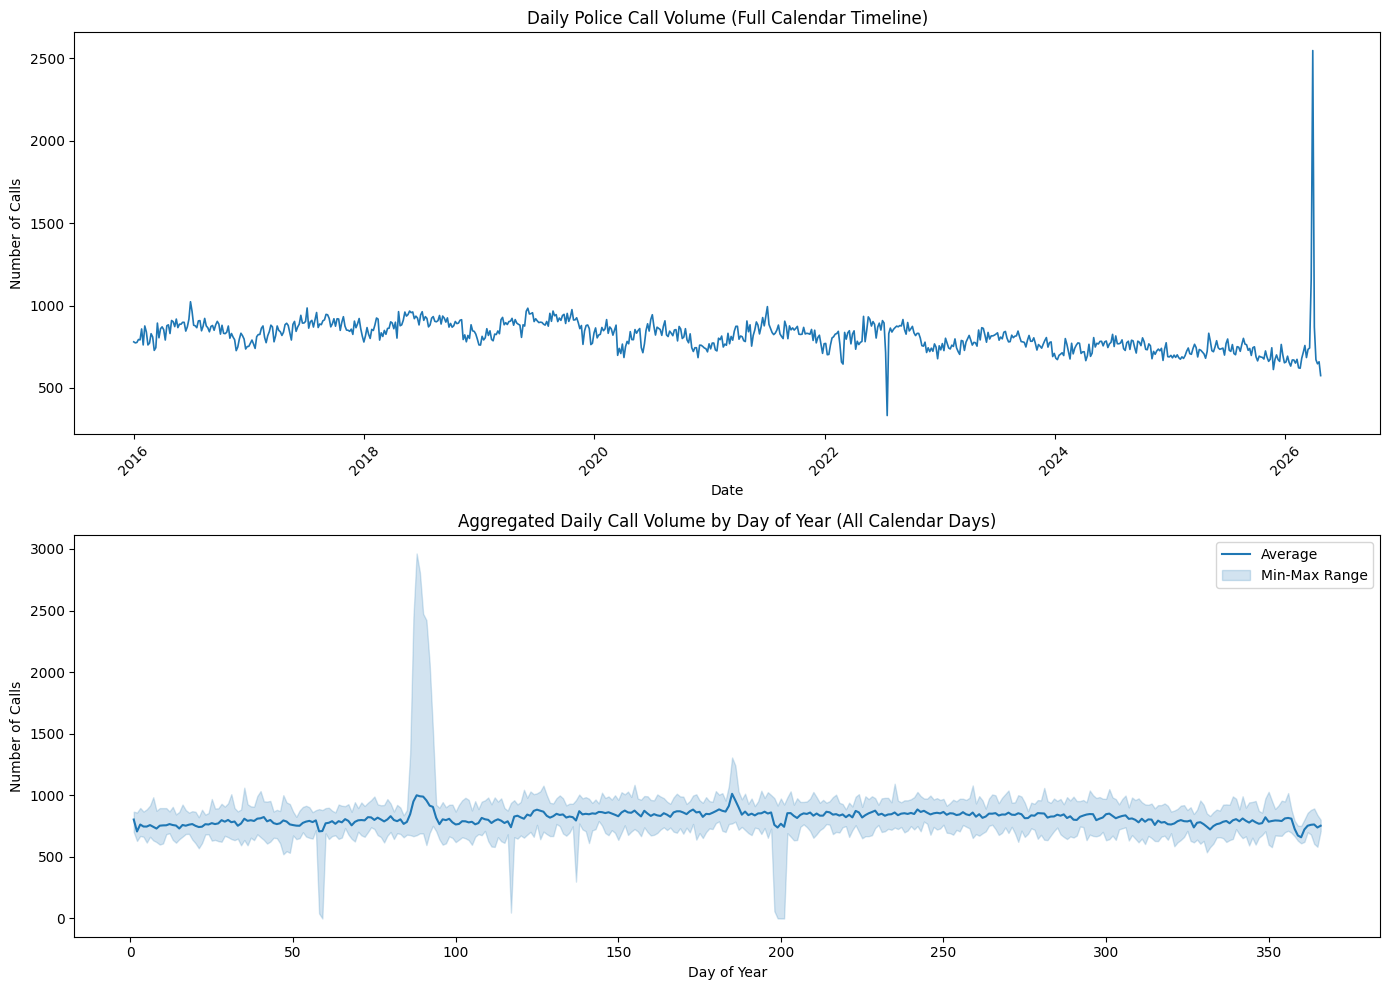

,day_of_year,avg_calls,min_calls,max_calls,sample_days
0,1,803.272727,702,867,11
1,2,706.272727,629,860,11
2,3,762.727273,670,897,11
3,4,746.454545,663,868,11
4,5,746.181818,616,886,11
5,6,758.272727,663,916,11
6,7,744.272727,634,984,11
7,8,730.000000,620,874,11
8,9,753.272727,600,896,11
9,10,755.727273,609,896,11


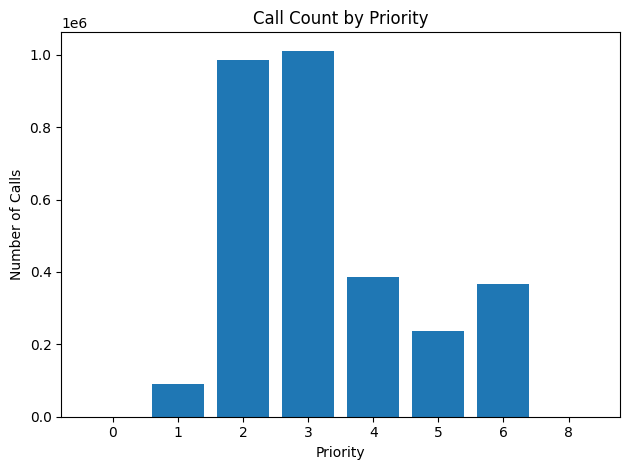

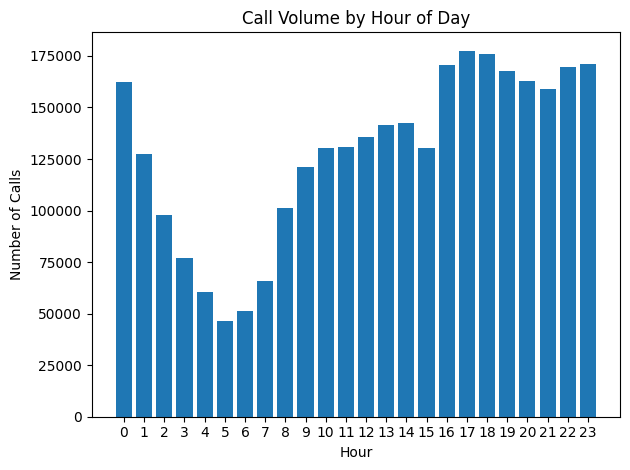

In [6]:
# Reuse pre-aggregated daily counts to avoid re-scanning the full dataframe.
daily_observed = daily_calls.copy()
daily_observed["day"] = pd.to_datetime(daily_observed["day"])

# Build a full calendar timeline and fill missing days with 0 so every day is represented.
full_day_index = pd.date_range(
    daily_observed["day"].min(), daily_observed["day"].max(), freq="D"
)
daily_timeline = (
    daily_observed.set_index("day")
    .reindex(full_day_index, fill_value=0)
    .rename_axis("day")
    .reset_index()
    .rename(columns={"index": "day"})
)
daily_timeline["total_calls"] = daily_timeline["total_calls"].astype("int32")

missing_day_count = int(len(full_day_index) - len(daily_observed))
print(f"Filled {missing_day_count:,} missing calendar days with 0 calls.")

# Keep plotting responsive by downsampling only for visualization when needed.
daily_plot = daily_timeline
max_daily_points = 900
if len(daily_plot) > max_daily_points:
    plot_bin_days = max(int(np.ceil(len(daily_plot) / max_daily_points)), 1)
    daily_plot = (
        daily_plot.set_index("day")["total_calls"]
        .resample(f"{plot_bin_days}D")
        .mean()
        .reset_index()
    )
    print(
        f"Daily chart downsampled to {len(daily_plot):,} points using {plot_bin_days}-day bins."
    )
else:
    print(f"Daily chart uses full daily resolution ({len(daily_plot):,} points).")

# Aggregate all calendar days-of-year (1..366) from the full timeline.
doy_stats = (
    daily_timeline.assign(day_of_year=daily_timeline["day"].dt.dayofyear)
    .groupby("day_of_year", sort=True, as_index=True)["total_calls"]
    .agg(avg_calls="mean", min_calls="min", max_calls="max", sample_days="size")
)

# Fast fixed-size index to guarantee full 1..366 coverage.
doy_profile = (
    doy_stats.reindex(np.arange(1, 367)).rename_axis("day_of_year").reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(daily_plot["day"], daily_plot["total_calls"], linewidth=1.2)
axes[0].set_title("Daily Police Call Volume (Full Calendar Timeline)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Number of Calls")
axes[0].tick_params(axis="x", rotation=45)

valid_doy = doy_profile.dropna(subset=["avg_calls", "min_calls", "max_calls"])
axes[1].plot(
    valid_doy["day_of_year"], valid_doy["avg_calls"], color="tab:blue", label="Average"
)
axes[1].fill_between(
    valid_doy["day_of_year"],
    valid_doy["min_calls"],
    valid_doy["max_calls"],
    color="tab:blue",
    alpha=0.2,
    label="Min-Max Range",
)
axes[1].set_title("Aggregated Daily Call Volume by Day of Year (All Calendar Days)")
axes[1].set_xlabel("Day of Year")
axes[1].set_ylabel("Number of Calls")
axes[1].legend()

plt.tight_layout()
plt.show()

display(doy_profile.head(10))

plt.figure()
plt.bar(priority_counts["PRIORITY"].astype(str), priority_counts["count"])
plt.title("Call Count by Priority")
plt.xlabel("Priority")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(hourly_calls["hour"].astype(str), hourly_calls["total_calls"])
plt.title("Call Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()

## Workload and cancellation patterns by weekday and hour

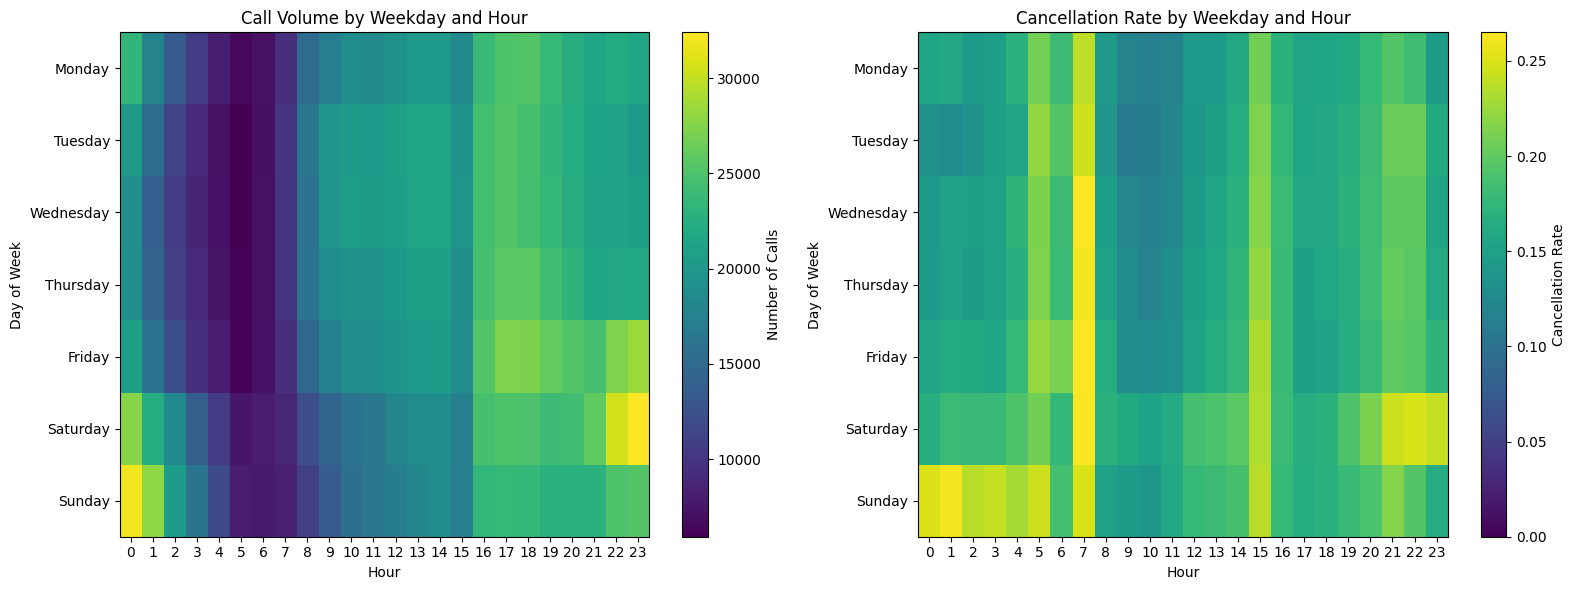

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,23344,17724,13591,10557,8171,6485,7098,9622,15163,17364,...,20164,18581,23801,25077,25219,23636,22517,21640,22232,21571
Tuesday,20390,15173,11346,9076,7154,5925,7003,10028,16351,19719,...,21602,19498,24438,25336,24705,23361,22279,21320,21230,20398
Wednesday,18942,13873,10716,8668,7253,6123,7155,9924,16010,19725,...,21605,19809,24379,25328,24598,23597,22375,21145,21191,20990
Thursday,19096,14369,10985,9047,7331,6140,7088,9865,15968,18782,...,20840,18961,24568,25661,25592,24307,23155,21584,21941,21759
Friday,20902,15968,12322,9642,7927,6210,7263,9464,14739,17582,...,20560,18659,25355,27324,27157,25997,25234,24551,27244,28503


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,0.156,0.160,0.146,0.148,0.170,0.210,0.182,0.239,0.144,0.118,...,0.160,0.209,0.171,0.155,0.157,0.161,0.177,0.193,0.183,0.145
Tuesday,0.134,0.127,0.136,0.150,0.155,0.222,0.194,0.246,0.138,0.110,...,0.164,0.214,0.177,0.156,0.160,0.167,0.182,0.206,0.205,0.161
Wednesday,0.144,0.152,0.149,0.152,0.172,0.213,0.181,0.264,0.150,0.123,...,0.169,0.217,0.181,0.160,0.160,0.171,0.183,0.198,0.198,0.155
Thursday,0.145,0.153,0.147,0.153,0.168,0.214,0.181,0.260,0.153,0.128,...,0.174,0.222,0.178,0.151,0.157,0.165,0.183,0.202,0.197,0.162
Friday,0.154,0.162,0.161,0.156,0.178,0.223,0.212,0.265,0.164,0.131,...,0.177,0.232,0.178,0.151,0.153,0.164,0.179,0.199,0.195,0.172


In [7]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

workload_heat = (
    df.groupby(["day_of_week", "hour"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(day_order)
    .reindex(columns=range(24), fill_value=0)
)

cancel_rate_heat = df.groupby(["day_of_week", "hour"], observed=False).agg(
    total_calls=("CDTS", "size"), canceled_calls=("is_canceled", "sum")
)
cancel_rate_heat["cancel_rate"] = np.where(
    cancel_rate_heat["total_calls"] > 0,
    cancel_rate_heat["canceled_calls"] / cancel_rate_heat["total_calls"],
    np.nan,
)
cancel_rate_heat = (
    cancel_rate_heat["cancel_rate"]
    .unstack()
    .reindex(day_order)
    .reindex(columns=range(24))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

workload_im = axes[0].imshow(workload_heat, aspect="auto")
axes[0].set_title("Call Volume by Weekday and Hour")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Day of Week")
axes[0].set_xticks(range(24))
axes[0].set_yticks(range(len(workload_heat.index)), workload_heat.index)
fig.colorbar(workload_im, ax=axes[0], label="Number of Calls")

cancel_im = axes[1].imshow(
    cancel_rate_heat, aspect="auto", vmin=0, vmax=np.nanmax(cancel_rate_heat.to_numpy())
)
axes[1].set_title("Cancellation Rate by Weekday and Hour")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Day of Week")
axes[1].set_xticks(range(24))
axes[1].set_yticks(range(len(cancel_rate_heat.index)), cancel_rate_heat.index)
fig.colorbar(cancel_im, ax=axes[1], label="Cancellation Rate")

plt.tight_layout()
plt.show()

display(workload_heat.head())
display(cancel_rate_heat.round(3).head())

## Aggregate the data into operational workload windows

In [8]:
time_bin_size = "15min"
df["time_bin"] = df["CDTS"].dt.floor(time_bin_size)

df["is_priority_1"] = (df["PRIORITY"] == 1).astype("int8")

agg = df.groupby("time_bin", as_index=False).agg(
    total_calls=("CDTS", "size"),
    canceled_calls=("is_canceled", "sum"),
    priority_1_calls=("is_priority_1", "sum"),
    unique_call_types=("CALL_TYPE", "nunique"),
)

agg["cancel_rate"] = np.where(
    agg["total_calls"] > 0, agg["canceled_calls"] / agg["total_calls"], np.nan
)
agg["priority_1_share"] = np.where(
    agg["total_calls"] > 0, agg["priority_1_calls"] / agg["total_calls"], np.nan
)

display(agg.head())
display(
    agg[
        [
            "total_calls",
            "canceled_calls",
            "cancel_rate",
            "priority_1_share",
            "unique_call_types",
        ]
    ].describe()
)

,time_bin,total_calls,canceled_calls,priority_1_calls,unique_call_types,cancel_rate,priority_1_share
0,2016-01-01 00:00:00,10,8,2,4,0.800000,0.200000
1,2016-01-01 00:15:00,14,10,0,6,0.714286,0.000000
2,2016-01-01 00:30:00,18,8,0,8,0.444444,0.000000
3,2016-01-01 00:45:00,11,3,3,8,0.272727,0.272727
4,2016-01-01 01:00:00,5,3,0,4,0.600000,0.000000


,total_calls,canceled_calls,cancel_rate,priority_1_share,unique_call_types
count,358050.000000,358050.000000,358050.000000,358050.000000,358050.000000
mean,8.593423,1.496609,0.174265,0.032972,6.855224
std,4.495966,1.589103,0.175229,0.082854,3.136902
min,1.000000,0.000000,0.000000,0.000000,1.000000
25%,5.000000,0.000000,0.000000,0.000000,5.000000
50%,8.000000,1.000000,0.142857,0.000000,7.000000
75%,11.000000,2.000000,0.250000,0.000000,9.000000
max,80.000000,38.000000,1.000000,1.000000,23.000000


## Plot operational surge indicators

Plot downsampled to 1,501 points using 217109s bins.


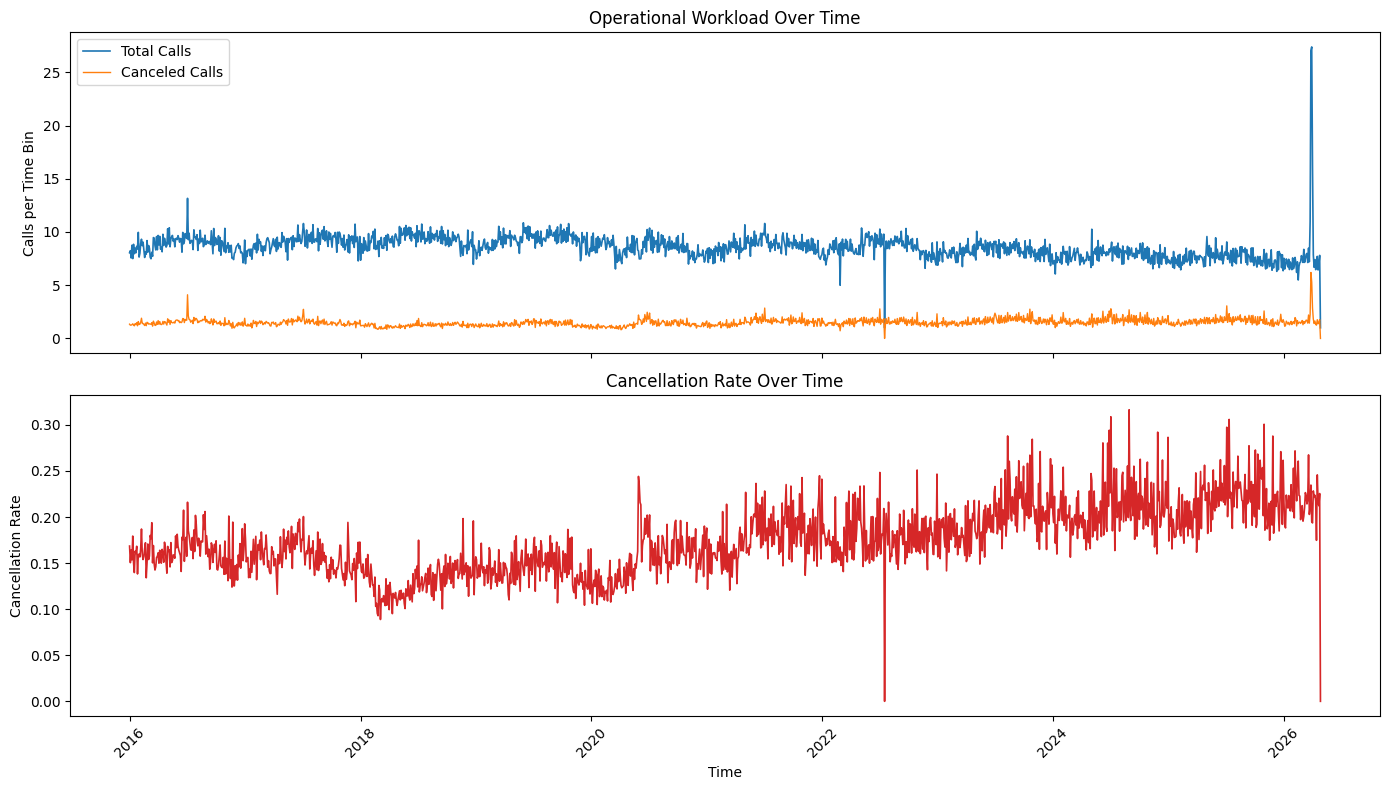

In [9]:
plot_agg = agg.sort_values("time_bin").copy()
max_plot_points = 1500

if len(plot_agg) > max_plot_points:
    total_span_seconds = max(
        (plot_agg["time_bin"].max() - plot_agg["time_bin"].min()).total_seconds(), 1
    )
    resample_seconds = max(int(total_span_seconds / max_plot_points), 1)
    resample_rule = f"{resample_seconds}s"

    plot_agg = (
        plot_agg.set_index("time_bin")[["total_calls", "canceled_calls", "cancel_rate"]]
        .resample(resample_rule)
        .mean()
        .dropna(how="all")
        .reset_index()
    )
    print(f"Plot downsampled to {len(plot_agg):,} points using {resample_rule} bins.")
else:
    print(f"Plot uses full resolution ({len(plot_agg):,} points).")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(
    plot_agg["time_bin"], plot_agg["total_calls"], label="Total Calls", linewidth=1.2
)
axes[0].plot(
    plot_agg["time_bin"],
    plot_agg["canceled_calls"],
    label="Canceled Calls",
    linewidth=1.0,
)
axes[0].set_title("Operational Workload Over Time")
axes[0].set_ylabel("Calls per Time Bin")
axes[0].legend()

axes[1].plot(
    plot_agg["time_bin"], plot_agg["cancel_rate"], color="tab:red", linewidth=1.2
)
axes[1].set_title("Cancellation Rate Over Time")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Cancellation Rate")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Compare calm and busy workload windows

In [10]:
agg["workload_band"] = pd.qcut(
    agg["total_calls"],
    q=4,
    labels=["Low", "Moderate", "High", "Very High"],
    duplicates="drop",
)

workload_compare = (
    agg.groupby("workload_band", observed=False)
    .agg(
        windows=("time_bin", "count"),
        avg_total_calls=("total_calls", "mean"),
        avg_canceled_calls=("canceled_calls", "mean"),
        avg_cancel_rate=("cancel_rate", "mean"),
        avg_unique_call_types=("unique_call_types", "mean"),
    )
    .reset_index()
)

display(workload_compare)

,workload_band,windows,avg_total_calls,avg_canceled_calls,avg_cancel_rate,avg_unique_call_types
0,Low,97001,3.467531,0.620849,0.182280,3.185627
1,Moderate,90570,7.017533,1.185768,0.169132,6.016661
2,High,83100,9.935788,1.668014,0.167826,8.064597
3,Very High,87379,14.640577,2.627988,0.176813,10.647947


## Find highest-demand windows and locations

,time_bin,total_calls,canceled_calls,priority_1_calls,unique_call_types,cancel_rate,priority_1_share,workload_band
355296,2026-03-28 23:45:00,80,27,3,16,0.337500,0.037500,Very High
355294,2026-03-28 23:15:00,79,15,0,11,0.189873,0.000000,Very High
355464,2026-03-30 18:15:00,76,20,8,14,0.263158,0.105263,Very High
355461,2026-03-30 17:30:00,67,24,8,14,0.358209,0.119403,Very High
355463,2026-03-30 18:00:00,67,4,0,15,0.059701,0.000000,Very High
355304,2026-03-29 01:45:00,66,11,4,14,0.166667,0.060606,Very High
355388,2026-03-29 23:00:00,65,20,0,13,0.307692,0.000000,Very High
355635,2026-04-01 13:00:00,64,16,0,15,0.250000,0.000000,Very High
355469,2026-03-30 19:30:00,64,0,0,12,0.000000,0.000000,Very High
355639,2026-04-01 14:00:00,61,12,0,11,0.196721,0.000000,Very High


,ADDRESS,total_calls,canceled_calls,cancel_rate
0,[2800]-[2900] STEVENS CREEK BL,6896,2619,0.379785
1,[200]-[300] W MISSION ST,6761,782,0.115663
2,Not a valid geographical locat,6428,1053,0.163815
3,[2100]-[2200] MONTEREY RD,5972,811,0.135800
4,[1700]-[1800] AIRPORT BL,5572,324,0.058148
5,[900]-[1000] BLOSSOM HILL RD,5263,1123,0.213376
6,[900]-[1000] BLOSSOM HILL RD,4708,1299,0.275913
7,[2000]-[2100] AIRPORT BL,4644,294,0.063307
8,[2800]-[2900] STEVENS CREEK BL,4590,1497,0.326144
9,[2100]-[2200] MONTEREY RD,4490,665,0.148107


,CITY,total_calls
0,San Jose,3076875


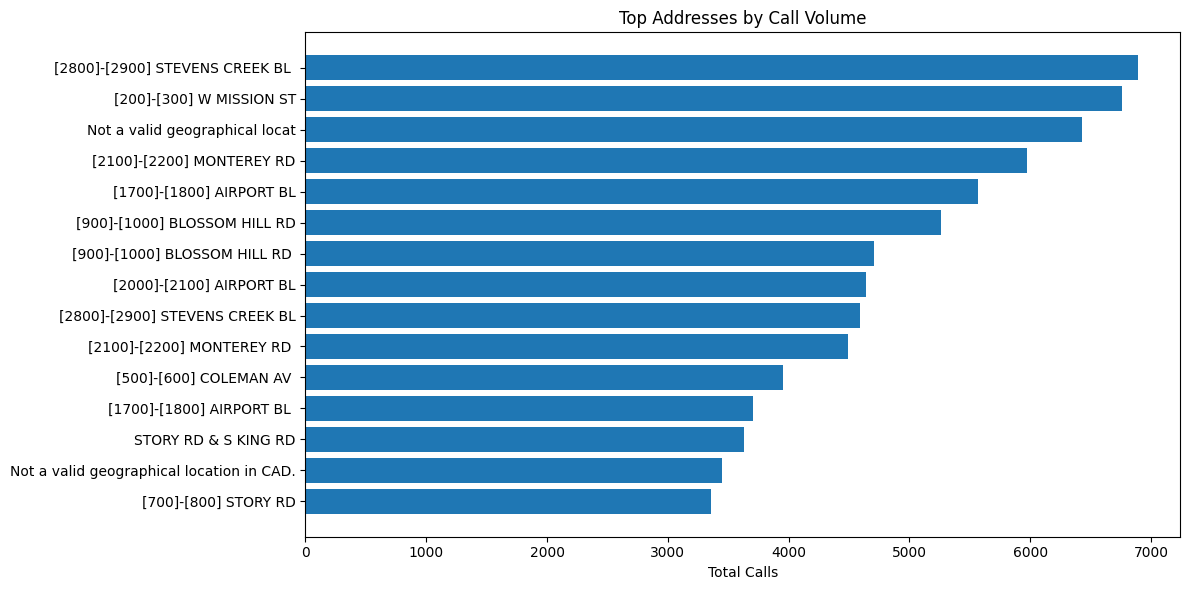

In [11]:
top_stress_windows = agg.sort_values(
    ["total_calls", "canceled_calls", "cancel_rate"], ascending=[False, False, False]
).head(20)

top_addresses = (
    df.dropna(subset=["ADDRESS"])
    .groupby("ADDRESS", observed=False)
    .agg(total_calls=("CDTS", "size"), canceled_calls=("is_canceled", "sum"))
)
top_addresses["cancel_rate"] = np.where(
    top_addresses["total_calls"] > 0,
    top_addresses["canceled_calls"] / top_addresses["total_calls"],
    np.nan,
)
top_addresses = (
    top_addresses.sort_values(
        ["total_calls", "canceled_calls"], ascending=[False, False]
    )
    .head(15)
    .reset_index()
)

top_cities = (
    df.dropna(subset=["CITY"])
    .groupby("CITY", observed=False)
    .agg(total_calls=("CDTS", "size"))
    .sort_values("total_calls", ascending=False)
    .head(10)
    .reset_index()
)

display(top_stress_windows)
display(top_addresses)
display(top_cities)

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(top_addresses["ADDRESS"].iloc[::-1], top_addresses["total_calls"].iloc[::-1])
ax.set_title("Top Addresses by Call Volume")
ax.set_xlabel("Total Calls")

plt.tight_layout()
plt.show()

## Profile call types and dispositions

,CALL_TYPE,total_calls,canceled_calls,priority_1_calls,cancel_rate,priority_1_share
0,DISTURBANCE,299041,71318,1509,0.238489,0.005046
1,VEHICLE STOP,274234,2582,69,0.009415,0.000252
2,"ALARM, AUDIBLE",220163,79834,4548,0.362613,0.020657
3,WELFARE CHECK,218883,37360,1966,0.170685,0.008982
4,PARKING VIOLATION,154518,20290,11,0.131312,0.000071
5,SUSPICIOUS VEHICLE,109270,16861,29,0.154306,0.000265
6,"DISTURBANCE, FAMILY",106434,13501,740,0.126849,0.006953
7,SUSPICIOUS PERSON,93753,21523,375,0.229571,0.004000
8,"DISTURBANCE, MUSIC",88573,54894,7,0.619760,0.000079
9,STOLEN VEHICLE,82338,5453,284,0.066227,0.003449


,FINAL_DISPO,total_calls
0,No report required; dispatch r,736278
1,No report required; dispatch record only,628189
2,Canceled,535861
3,Report taken,382787
4,No Disposition,123111
5,Gone on Arrival/unable to loca,105631
6,No Response,64690
7,Arrest Made,61663
8,Gone on Arrival/unable to locate,60667
9,Supplemental report taken,52090


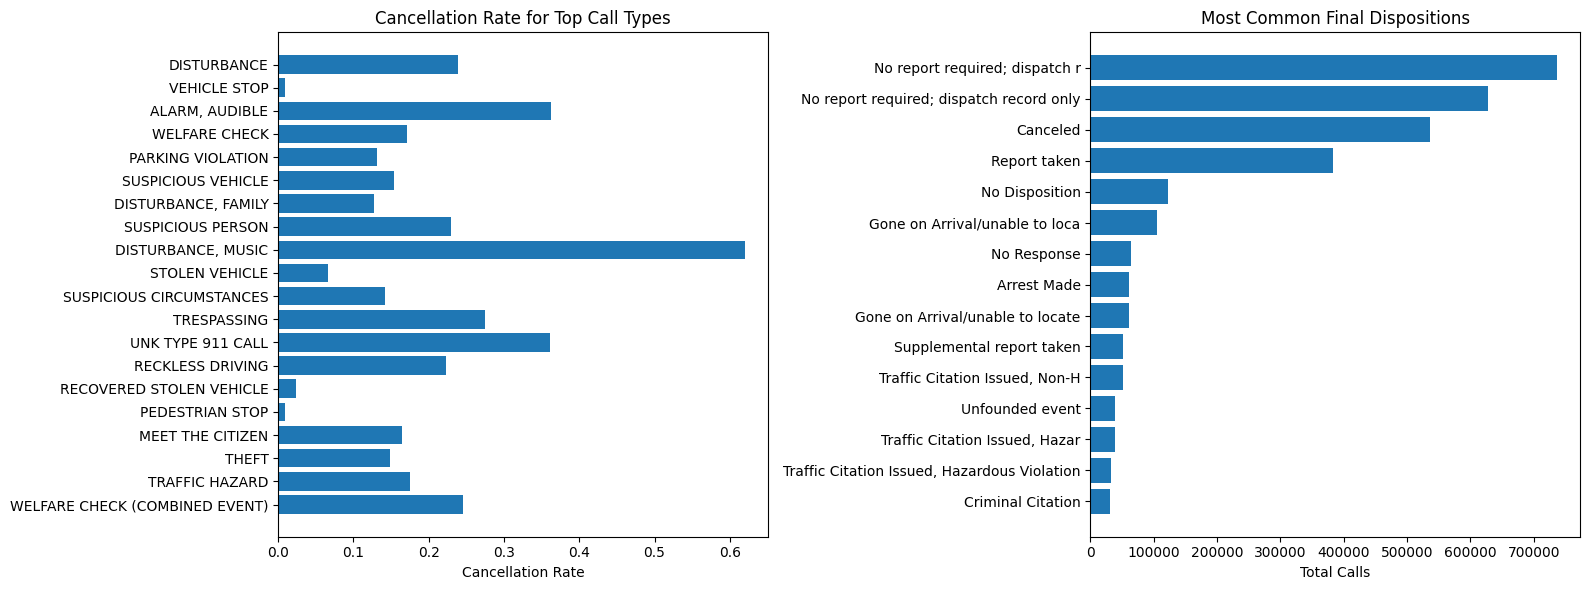

In [12]:
call_type_profile = df.groupby("CALL_TYPE", observed=False).agg(
    total_calls=("CDTS", "size"),
    canceled_calls=("is_canceled", "sum"),
    priority_1_calls=("is_p1", "sum"),
)
call_type_profile["cancel_rate"] = np.where(
    call_type_profile["total_calls"] > 0,
    call_type_profile["canceled_calls"] / call_type_profile["total_calls"],
    np.nan,
)
call_type_profile["priority_1_share"] = np.where(
    call_type_profile["total_calls"] > 0,
    call_type_profile["priority_1_calls"] / call_type_profile["total_calls"],
    np.nan,
)
call_type_profile = (
    call_type_profile.sort_values("total_calls", ascending=False).head(20).reset_index()
)

disposition_profile = (
    df.groupby("FINAL_DISPO", observed=False)
    .agg(total_calls=("CDTS", "size"))
    .sort_values("total_calls", ascending=False)
    .head(15)
    .reset_index()
)

display(call_type_profile)
display(disposition_profile)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    call_type_profile["CALL_TYPE"].iloc[::-1],
    call_type_profile["cancel_rate"].iloc[::-1],
)
axes[0].set_title("Cancellation Rate for Top Call Types")
axes[0].set_xlabel("Cancellation Rate")

axes[1].barh(
    disposition_profile["FINAL_DISPO"].iloc[::-1],
    disposition_profile["total_calls"].iloc[::-1],
)
axes[1].set_title("Most Common Final Dispositions")
axes[1].set_xlabel("Total Calls")

plt.tight_layout()
plt.show()

## Inspect one high-demand event window

In [13]:
if not top_stress_windows.empty:
    selected_window = top_stress_windows.iloc[0]["time_bin"]
    start_window = selected_window - pd.Timedelta(minutes=30)
    end_window = selected_window + pd.Timedelta(minutes=30)

    event_slice = df[(df["CDTS"] >= start_window) & (df["CDTS"] <= end_window)].copy()
    event_slice = event_slice.sort_values("CDTS")

    print("High-demand window:", start_window, "to", end_window)
    print("Calls in window:", len(event_slice))

    cols_to_show = ["CDTS", "PRIORITY", "CALL_TYPE", "FINAL_DISPO"]
    if "ADDRESS" in event_slice.columns:
        cols_to_show.append("ADDRESS")
    if "CITY" in event_slice.columns:
        cols_to_show.append("CITY")

    display(event_slice[cols_to_show])

High-demand window: 2026-03-28 23:15:00 to 2026-03-29 00:15:00
Calls in window: 245


,CDTS,PRIORITY,CALL_TYPE,FINAL_DISPO,ADDRESS,CITY
3035512,2026-03-28 23:15:03,6,VEHICLE STOP,"Traffic Citation Issued, Non-Hazardous Violation",SENTER RD & EZIE ST,San Jose
3049198,2026-03-28 23:15:03,6,VEHICLE STOP,"Traffic Citation Issued, Non-Hazardous Violation",SENTER RD & EZIE ST,San Jose
3045760,2026-03-28 23:15:03,6,VEHICLE STOP,"Traffic Citation Issued, Non-Hazardous Violation",SENTER RD & EZIE ST,San Jose
3035145,2026-03-28 23:16:11,3,"DISTURBANCE, FAMILY",No report required; dispatch record only,[5700]-[5800] VIA MONTE DR,San Jose
3049217,2026-03-28 23:16:17,6,PEDESTRIAN STOP,No report required; dispatch record only,S 1ST ST & KEYES ST,San Jose
...,...,...,...,...,...,...
3045873,2026-03-29 00:13:52,3,MALICIOUS MISCHIEF,Report taken,[1700]-[1800] E CAPITOL EX,San Jose
3049329,2026-03-29 00:13:52,3,MALICIOUS MISCHIEF,Report taken,[1700]-[1800] E CAPITOL EX,San Jose
3035853,2026-03-29 00:13:52,3,MALICIOUS MISCHIEF,Report taken,[1700]-[1800] E CAPITOL EX,San Jose
3045541,2026-03-29 00:14:42,1,ASSAULT WITH DEADLY WEAPON,Report taken,[1300]-[1400] S BASCOM AV,San Jose


## Detailed calls inside the selected high-demand window

,CALL_TYPE,total_calls
0,VEHICLE STOP,81
1,"DISTURBANCE, MUSIC",39
2,DISTURBANCE,16
3,SUSPICIOUS VEHICLE,15
4,MALICIOUS MISCHIEF,6
5,WELFARE CHECK,6
6,PEDESTRIAN STOP,6
7,TRESPASSING,6
8,MENTALLY DISTURBED PERSON,6
9,UNK TYPE 911 CALL,6


,PRIORITY,total_calls
0,1,8
1,2,37
2,3,56
3,4,48
4,5,9
5,6,87


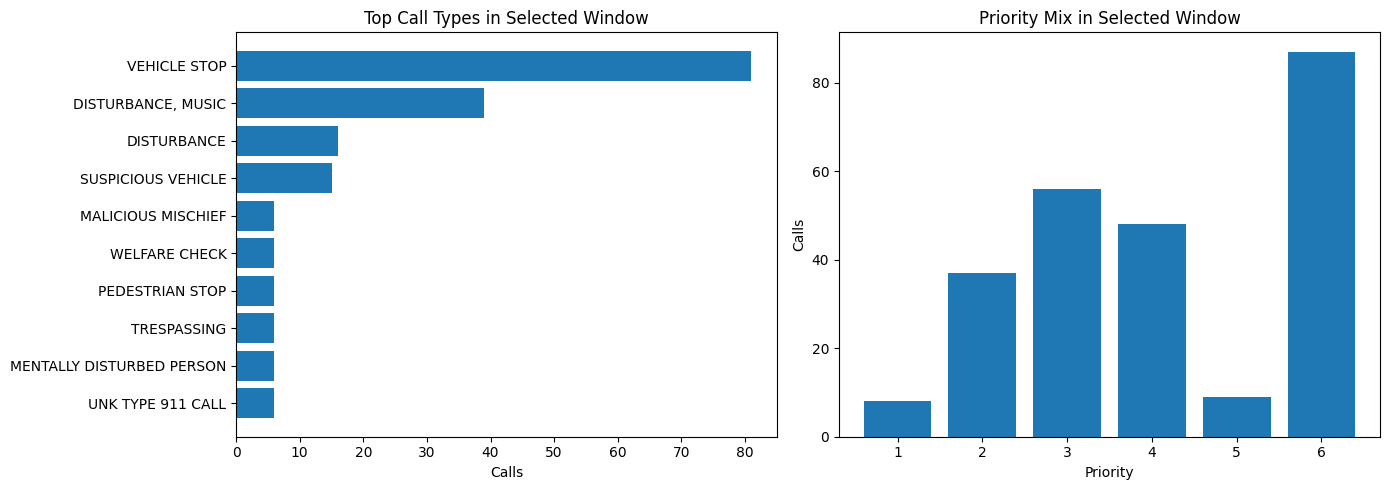

In [14]:
if not top_stress_windows.empty and not event_slice.empty:
    window_call_mix = (
        event_slice.groupby("CALL_TYPE", observed=False)
        .size()
        .sort_values(ascending=False)
        .head(10)
        .reset_index(name="total_calls")
    )

    window_priority_mix = (
        event_slice.groupby("PRIORITY", observed=False)
        .size()
        .sort_index()
        .reset_index(name="total_calls")
    )

    display(window_call_mix)
    display(window_priority_mix)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].barh(
        window_call_mix["CALL_TYPE"].iloc[::-1],
        window_call_mix["total_calls"].iloc[::-1],
    )
    axes[0].set_title("Top Call Types in Selected Window")
    axes[0].set_xlabel("Calls")

    axes[1].bar(
        window_priority_mix["PRIORITY"].astype(str), window_priority_mix["total_calls"]
    )
    axes[1].set_title("Priority Mix in Selected Window")
    axes[1].set_xlabel("Priority")
    axes[1].set_ylabel("Calls")

    plt.tight_layout()
    plt.show()

## Build monthly and yearly workload summaries

,year,month,total_calls,canceled_calls,priority_1_calls,cancel_rate,priority_1_share
0,2016,1,24717,3942,602,0.159485,0.024356
1,2016,2,23345,3924,588,0.168087,0.025187
2,2016,3,25015,4033,667,0.161223,0.026664
3,2016,4,25633,4146,719,0.161745,0.028050
4,2016,5,27659,4660,681,0.168480,0.024621
...,...,...,...,...,...,...,...
119,2025,12,21301,4435,636,0.208206,0.029858
120,2026,1,20631,4232,552,0.205128,0.026756
121,2026,2,18425,4119,566,0.223555,0.030719
122,2026,3,30668,6481,804,0.211328,0.026216


,year,total_calls,canceled_calls,priority_1_calls,cancel_rate,priority_1_share
0,2016,309210,52634,8437,0.170221,0.027286
1,2017,316172,51479,8552,0.162820,0.027049
2,2018,322364,42523,8958,0.131910,0.027788
3,2019,322609,46818,8820,0.145123,0.027340
4,2020,297477,46241,9181,0.155444,0.030863
5,2021,302104,53441,9269,0.176896,0.030681
6,2022,294529,52034,9186,0.176669,0.031189
7,2023,286471,57327,9296,0.200114,0.032450
8,2024,272508,57694,8894,0.211715,0.032638
9,2025,262109,56405,8266,0.215197,0.031536


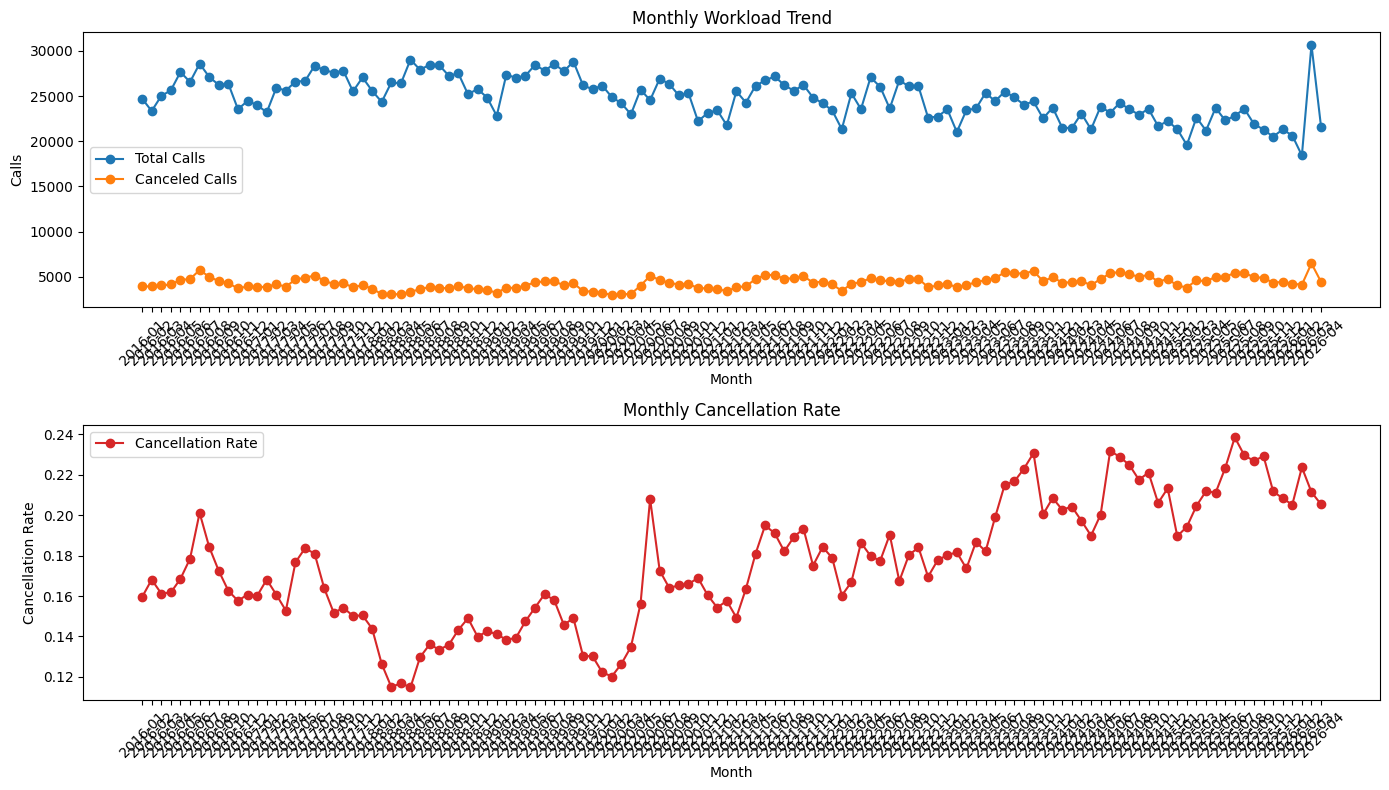

In [15]:
monthly_summary = (
    df.groupby(["year", "month"], observed=False)
    .agg(
        total_calls=("CDTS", "size"),
        canceled_calls=("is_canceled", "sum"),
        priority_1_calls=("is_p1", "sum"),
    )
    .reset_index()
)

monthly_summary["cancel_rate"] = np.where(
    monthly_summary["total_calls"] > 0,
    monthly_summary["canceled_calls"] / monthly_summary["total_calls"],
    np.nan,
)
monthly_summary["priority_1_share"] = np.where(
    monthly_summary["total_calls"] > 0,
    monthly_summary["priority_1_calls"] / monthly_summary["total_calls"],
    np.nan,
)

yearly_summary = (
    df.groupby("year", observed=False)
    .agg(
        total_calls=("CDTS", "size"),
        canceled_calls=("is_canceled", "sum"),
        priority_1_calls=("is_p1", "sum"),
    )
    .reset_index()
)

yearly_summary["cancel_rate"] = np.where(
    yearly_summary["total_calls"] > 0,
    yearly_summary["canceled_calls"] / yearly_summary["total_calls"],
    np.nan,
)
yearly_summary["priority_1_share"] = np.where(
    yearly_summary["total_calls"] > 0,
    yearly_summary["priority_1_calls"] / yearly_summary["total_calls"],
    np.nan,
)

monthly_summary = monthly_summary.sort_values(["year", "month"]).reset_index(drop=True)
yearly_summary = yearly_summary.sort_values("year").reset_index(drop=True)

display(monthly_summary)
display(yearly_summary)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

month_labels = (
    monthly_summary["year"].astype(str)
    + "-"
    + monthly_summary["month"].astype(str).str.zfill(2)
)
axes[0].plot(
    month_labels, monthly_summary["total_calls"], marker="o", label="Total Calls"
)
axes[0].plot(
    month_labels, monthly_summary["canceled_calls"], marker="o", label="Canceled Calls"
)
axes[0].set_title("Monthly Workload Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Calls")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].plot(
    month_labels,
    monthly_summary["cancel_rate"],
    marker="o",
    color="tab:red",
    label="Cancellation Rate",
)
axes[1].set_title("Monthly Cancellation Rate")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Cancellation Rate")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## Print a compact workload EDA summary

In [16]:
busiest_day_row = daily_calls.loc[daily_calls["total_calls"].idxmax()]
top_call_type_row = call_type_profile.iloc[0] if not call_type_profile.empty else None
top_address_row = top_addresses.iloc[0] if not top_addresses.empty else None

summary_stats = {
    "total_rows_after_cleaning": int(len(df)),
    "date_min": df["CDTS"].min(),
    "date_max": df["CDTS"].max(),
    "total_canceled_calls": int(df["is_canceled"].sum()),
    "overall_cancel_rate": float(df["is_canceled"].mean()),
    "busiest_day": busiest_day_row["day"],
    "busiest_day_calls": int(busiest_day_row["total_calls"]),
    "avg_calls_per_day": float(daily_calls["total_calls"].mean()),
    "top_call_type": None
    if top_call_type_row is None
    else top_call_type_row["CALL_TYPE"],
    "top_call_type_volume": None
    if top_call_type_row is None
    else int(top_call_type_row["total_calls"]),
    "top_address": None if top_address_row is None else top_address_row["ADDRESS"],
    "top_address_volume": None
    if top_address_row is None
    else int(top_address_row["total_calls"]),
}

print("\nWorkload EDA Summary Stats")
for key, value in summary_stats.items():
    print(f"{key}: {value}")


Workload EDA Summary Stats
total_rows_after_cleaning: 3076875
date_min: 2016-01-01 00:03:35
date_max: 2026-04-27 06:29:31
total_canceled_calls: 535861
overall_cancel_rate: 0.17415754621165955
busiest_day: 2026-03-29 00:00:00
busiest_day_calls: 2963
avg_calls_per_day: 816.7971860897266
top_call_type: DISTURBANCE
top_call_type_volume: 299041
top_address: [2800]-[2900] STEVENS CREEK BL 
top_address_volume: 6896
